# Installs and imports

In [2]:
#!python3 -m pip install pandas
#!python3 -m pip install scipy
#!python3 -m pip install matplotlib
#!python3 -m pip install tqdm
#!python3 -m pip install ipywidgets
#!jupyter nbextension enable --py widgetsnbextension

In [ ]:
import pickle
import csv
import pandas
import sys
import math
import scipy.stats as stats
import random
import numpy as np
import copy as cp
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from scipy.stats import pearsonr

In [ ]:
# ============================================================
# Load LRP explanations and model accuracies
# ============================================================

all_expls = {"ft": [], "human": []}     # explanation storage per model
accuracies = {"ft": []}                 # accuracy per model seed

model_name = "ft"
count = 0

# Load LRP explanations saved as sequential pickle objects
with open("NeededFiles/explanations_LRP.pickle", "rb") as f:
    while True:
        try:
            expls = pickle.load(f)
            all_expls[model_name].append(expls)
            count += 1
        except Exception:
            # Reached end of pickle file
            print(f"Loaded {count} explanation sets.")
            break


# Load model accuracies (one float per line)
with open("NeededFiles/model_accuracies", "r") as f:
    for line in f:
        accuracies["ft"].append(float(line.strip()))

200


# Compute Model Equivalence 

In [ ]:
# ============================================================
# Select sets of *equivalent models* based on accuracy
# ============================================================

def compute_epsilon(accuracies, n=50, best=False):
    """
    Find a subset of n models with similar accuracy.

    Parameters
    ----------
    accuracies : list[float]
        Accuracy per model seed.
    n : int
        Size of subset to select.
    best : bool
        If True → take top-n best models.
        If False → take n models with smallest accuracy range.

    Returns
    -------
    epsilon : float
        Accuracy range inside selected subset.
    indices : list[int]
        Indices of selected models.
    """
    
    # sort: (accuracy, original_index)
    sorted_acc = sorted([(acc, idx) for idx, acc in enumerate(accuracies)])

    if best:
        best_indices = [i[1] for i in sorted_acc[-n:]]
        best_epsilon = sorted_acc[-1][0] - sorted_acc[-n][0]
        return best_epsilon, best_indices

    # Sliding window to find smallest accuracy range
    closest_epsilon = sorted_acc[-1][0] - sorted_acc[-n][0]
    closest_indices = [i[1] for i in sorted_acc[-n:]]

    for start in range(len(sorted_acc) - n):
        epsilon = sorted_acc[start + n][0] - sorted_acc[start][0]
        if epsilon < closest_epsilon:
            closest_epsilon = epsilon
            closest_indices = [i[1] for i in sorted_acc[start:start+n]]

    return closest_epsilon, closest_indices

In [ ]:
# ============================================================
# Build subsets of equivalent models (best vs closest)
# ============================================================

equivalent_models_expls = {"ft": []}
equivalent_models_accs = {"ft": []}

model_name = "ft"

dict_expl_name, accs = {}, {}

accuracies_name = accuracies[model_name]
all_expls_name = all_expls[model_name]

# ----- BEST performing subsets -----
for n in [200, 150, 100, 50]:
    epsilon, indices = compute_epsilon(accuracies_name, n=n, best=True)
    accs[f"{n}_best"] = [v for i, v in enumerate(accuracies_name) if i in indices]
    dict_expl_name[f"{n}_best"] = [v for i, v in enumerate(all_expls_name) if i in indices]

# ----- MOST SIMILAR accuracy subsets -----
for n in [150, 100, 50]:
    epsilon, indices = compute_epsilon(accuracies_name, n=n, best=False)
    accs[f"{n}_closest"] = [v for i, v in enumerate(accuracies_name) if i in indices]
    dict_expl_name[f"{n}_closest"] = [v for i, v in enumerate(all_expls_name) if i in indices]

equivalent_models_accs[model_name] = accs
equivalent_models_expls[model_name] = dict_expl_name

In [ ]:
# from https://online.stat.psu.edu/stat415/lesson/9/9.4

# ============================================================
# Statistical comparison of accuracy ranges (z-score test)
# ============================================================

def z_score(p1, p2, n):
    """Two-proportion z-test helper."""
    P = (p1 + p2) / 2
    return (p1 - p2) / math.sqrt(P * (1 - P) / n)

for model_name, subsets in equivalent_models_accs.items():
    for subset, accs_subset in subsets.items():
        z = z_score(min(accs_subset), max(accs_subset), 1000)
        acc_range = (min(accs_subset), max(accs_subset))
        avg_acc = sum(accs_subset) / len(accs_subset)
        print(model_name, subset, acc_range, avg_acc, abs(z))

ft 200_best (0.911, 0.941) 0.92686 3.624097737145396
ft 150_best (0.923, 0.941) 0.9292866666666667 2.2610496162913862
ft 100_best (0.927, 0.941) 0.93116 1.7831284521209636
ft 50_best (0.93, 0.941) 0.9336200000000001 1.4160902477559283
ft 150_closest (0.92, 0.932) 0.9266066666666668 1.4496390948581648
ft 100_closest (0.923, 0.929) 0.9265000000000001 0.7248195474290824
ft 50_closest (0.93, 0.941) 0.9336200000000001 1.4160902477559283


# Post-processing of fine-tuned model explanations

In [ ]:
# ============================================================
# Post-processing LRP explanations
# ============================================================

# Order alignment between human annotations and LRP outputs
order_human = list(range(10))
order_lrp = [1, 6, 2, 7, 0, 3, 4, 9, 5, 8]

# Reorder explanations using the best 100 models
all_expls["ft"] = [[seed[i] for i in order_lrp] for seed in dict_expl_name["100_best"]]

In [ ]:
# Extract texts and prediction counts

texts_full = []
for text in all_expls["ft"][1]:
    texts_full.append(" ".join([token for _, token in text]))

preds = [[0, 0] for _ in range(10)]

for seed_idx, seed_expl in enumerate(all_expls["ft"]):
    for text_idx, text in enumerate(seed_expl):
        if seed_idx == 0:
            print(" ".join([token for _, token in text]))

        # Count predictions per class
        preds[text_idx][int(text[0][0] > 0)] += 1

preds

Une Américaine de NBR ans a plaidé coupable d' avoir tiré à bout portant sur son petit ami tandis qu' il serrait contre son torse une encyclopédie , croyant que le livre arrêterait les balles . Monalisa Perez a plaidé coupable d' homicide involontaire et a accepté de purger une peine de six mois d' emprisonnement . La peine doit encore être confirmée par un juge du Minnesota en début d' année prochaine , ont rapporté mardi des médias locaux . Pedro Ruiz , NBR ans , avait convaincu en juin sa petite amie de lui tirer dessus tandis qu' il se protégeait avec un livre épais . Le couple aspirait à devenir des stars d' internet et espérait que la vidéo fasse décoller leur chaîne YouTube .
Pas moins de NBR Belges ont effectué des transactions en Bourse ces trois dernières années . Un phénomène qui s' est accentué avec la crise . Les chiffres présentés ce lundi par la FSMA , l' autorité de contrôle des marchés financiers , sont vertigineux : au cours des trois dernières années , NBR Belges ont

[[0, 100],
 [0, 100],
 [100, 0],
 [0, 100],
 [0, 100],
 [43, 57],
 [96, 4],
 [100, 0],
 [100, 0],
 [0, 100]]

In [ ]:
# ============================================================
# Normalize explanation scores to [-1, 1]
# ============================================================

def normalize(expl, with_neg=False):
    """
    Normalize token relevance scores so max absolute value = 1.
    Optionally restore sign if explanation was globally negative.
    """
    words = [w for _, w in expl]
    vector = [v for v, _ in expl]

    neg_flag = sum(vector) < 0
    if neg_flag:
        vector = [-v for v in vector]

    max_val = max(vector)
    vector = [v / max_val for v in vector]

    if neg_flag and with_neg:
        vector = [-v for v in vector]

    return list(zip(vector, words))


# Apply normalization to all explanations
normalized_expls = []
for seed in all_expls["ft"]:
    seed_expl = [normalize(text, with_neg=True) for text in seed]
    normalized_expls.append(seed_expl)

all_expls["ft"] = normalized_expls

# Post-processing of human explanations

In [ ]:
# ============================================================
# Load and post-process HUMAN explanations
# ============================================================

import pandas as pd

human_expls = pd.read_csv("NeededFiles/human_annotations.csv")
all_expls["human"] = []

human_expls_preds = []   # (#opinion_highlights, #info_highlights) per annotator
text_idxs = []           # final label per text ("opin" or "info")

,tid_x,title,text,label,tid_y,confidence_opinion,confidence_information,text_type,highlights_opinion,highlights_information,tkns_highlights_opinion,tkns_highlights_information
0,1,Une Américaine plaide coupable d’avoir tué son...,Une Américaine de 20 ans a plaidé coupable d’a...,info,17,[3.0],"[5.0, 4.0, 4.0, 5.0, 5.0, 4.0, 5.0, 5.0, 5.0, ...","{'information': 42, 'opinion': 1}","['[{""start"": 0, ""end"": 24, ""color"": ""highlight...","['[{""start"": 0, ""end"": 24, ""color"": ""highlight...","[[('Une', 0.33), ('Américaine', 0.33), ('de', ...","[[('Une', 1), ('Américaine', 1), ('de', 1), ('..."
1,2,"Les Belges, de plus en plus conquis par la Bourse",Pas moins de 830 000 Belges ont effectué des t...,info,27,"[3.0, 4.0, 3.0, 2.0, 5.0, 3.0]","[5.0, 4.0, 3.0, 3.0, 4.0, 2.0, 3.0, 4.0, 2.0, ...","{'information': 36, 'opinion': 6}","['[{""start"": 109, ""end"": 141, ""color"": ""highli...","['[{""start"": 179, ""end"": 233, ""color"": ""highli...","[[('Pas', 0), ('moins', 0), ('de', 0), ('830',...","[[('Pas', 0), ('moins', 0), ('de', 0), ('830',..."
2,3,«Enjeux»: Quand j’entends le mot «liberté»…,Lorsque des militants d’extrême droite défilen...,opin,49,"[5.0, 5.0, 4.0, 4.0, 5.0, 5.0, 5.0, 4.0, 5.0, ...",[],{'opinion': 42},"['[{""start"": 130, ""end"": 146, ""color"": ""highli...",[],"[[('Lorsque', 0), ('des', 0), ('militants', 0)...",[]
3,4,Guerre au Proche-Orient : nouvelles frappes su...,Israël a commémoré ce lundi le premier anniver...,info,6,[4.0],"[3.0, 4.0, 4.0, 4.0, 5.0, 5.0, 5.0, 4.0, 5.0, ...","{'information': 40, 'opinion': 1}","['[{""start"": 307, ""end"": 394, ""color"": ""highli...","['[{""start"": 75, ""end"": 93, ""color"": ""highligh...","[[('Israël', 0), ('a', 0), ('commémoré', 0), (...","[[('Israël', 0), ('a', 0), ('commémoré', 0), (..."
4,5,Le Vacci bus prend ses quartiers à Saint-Josse...,La commune de Saint-Josse-ten-Noode souhaite p...,info,40,"[3.0, 3.0]","[5.0, 5.0, 5.0, 4.0, 5.0, 4.0, 5.0, 5.0, 5.0, ...","{'information': 39, 'opinion': 2}","['[{""start"": 123, ""end"": 152, ""color"": ""highli...","['[{""start"": 36, ""end"": 53, ""color"": ""highligh...","[[('La', 0), ('commune', 0), ('de', 0), ('Sain...","[[('La', 0), ('commune', 0), ('de', 0), ('Sain..."
5,6,Nollet et les mesures «absurdes»: exercer le p...,"« Aujourd’hui j’ai respecté la bulle, mais dep...",opin,16,"[5.0, 5.0, 5.0, 4.0, 3.0, 5.0, 5.0, 3.0, 5.0, ...",[],{'opinion': 42},"['[{""start"": 0, ""end"": 1, ""color"": ""highlight-...",[],"[[('«', 1), ('Aujourd’hui', 0), ('j’', 0), ('a...",[]
6,7,Edito : la concertation sociale à l’agonie,La voie semble toute tracée : le gouvernement ...,opin,52,"[3.0, 5.0, 5.0, 4.0, 5.0, 4.0, 5.0, 4.0, 5.0, ...",[2.0],"{'opinion': 40, 'information': 1}","['[{""start"": 8, ""end"": 14, ""color"": ""highlight...","['[{""start"": 45, ""end"": 54, ""color"": ""highligh...","[[('La', 0), ('voie', 0), ('semble', 1), ('tou...","[[('La', 0), ('voie', 0), ('semble', 0), ('tou..."
7,8,"Le voile, ce drapeau de l'islamisme",Il est important qu'un pays séculier puisse se...,opin,2,"[4.0, 3.0, 5.0, 5.0, 5.0, 2.0, 5.0, 3.0, 5.0, ...",[],{'opinion': 40},"['[{""start"": 0, ""end"": 16, ""color"": ""highlight...",[],"[[('Il', 1), ('est', 1), ('important', 1), (""q...",[]
8,9,"Après Damso, ne gardons que les Diables morale...","À l’Union belge de football, on a donc « viré ...",opin,13,"[4.0, 5.0, 5.0, 5.0, 5.0, 3.0, 5.0, 3.0, 5.0, ...",[],{'opinion': 40},"['[{""start"": 39, ""end"": 40, ""color"": ""highligh...",[],"[[('À', 0), ('l’', 0), ('Union', 0), ('belge',...",[]
9,10,Georges-Louis Bouchez s'insurge à propos de l'...,"Le président du MR, Georges-Louis Bouchez, s'e...",info,3,[],"[4.0, 2.0, 5.0, 4.0, 4.0, 4.0, 5.0, 5.0, 5.0, ...",{'information': 41},[],"['[{""start"": 0, ""end"": 42, ""color"": ""highlight...",[],"[[('Le', 1), ('président', 1), ('du', 1), ('MR..."


In [ ]:
# ============================================================
# Determine final human label and select corresponding highlights
# ============================================================

for idx, row in human_expls.iterrows():

    # Parse stored confidence lists (stored as strings like "[0.1,0.2]")
    conf_opin = (
        [float(x) for x in row["confidence_opinion"].strip("[]").split(",")]
        if row["confidence_opinion"] != "[]" else []
    )
    conf_info = (
        [float(x) for x in row["confidence_information"].strip("[]").split(",")]
        if row["confidence_information"] != "[]" else []
    )

    human_expls_preds.append((len(conf_opin), len(conf_info)))

    # Majority decision: which class received more highlighted tokens?
    if len(conf_opin) <= len(conf_info):
        text_idxs.append(("info", idx))
        all_expls["human"].append(row["tkns_highlights_information"])
        print(row)

    else:
        text_idxs.append(("opin", idx))
        all_expls["human"].append(row["tkns_highlights_opinion"])
        print(row)

tid_x                                                                          1
title                          Une Américaine plaide coupable d’avoir tué son...
text                           Une Américaine de 20 ans a plaidé coupable d’a...
label                                                                       info
tid_y                                                                         17
confidence_opinion                                                         [3.0]
confidence_information         [5.0, 4.0, 4.0, 5.0, 5.0, 4.0, 5.0, 5.0, 5.0, ...
text_type                                      {'information': 42, 'opinion': 1}
highlights_opinion             ['[{"start": 0, "end": 24, "color": "highlight...
highlights_information         ['[{"start": 0, "end": 24, "color": "highlight...
tkns_highlights_opinion        [[('Une', 0.33), ('Américaine', 0.33), ('de', ...
tkns_highlights_information    [[('Une', 1), ('Américaine', 1), ('de', 1), ('...
Name: 0, dtype: object
tid_x

In [ ]:
# ============================================================
# Parse serialized highlight tuples from CSV
# (stored as string representation of list of tuples)
# ============================================================

parsed_expls_list_full = []

for expl in all_expls["human"]:
    parsed_expls_list = []

    # split list of annotations
    parsed_expls = [e.strip("[]") for e in expl.split("], ")]

    for p_expl in parsed_expls:
        tuple_list = p_expl.strip("()").split("), (")
        parsed_tuple_list = []

        for tup in tuple_list:
            token, score = tup.strip("'").split(", ")
            parsed_tuple = (float(score), token.strip('"').strip("'"))
            parsed_tuple_list.append(parsed_tuple)

        parsed_expls_list.append(parsed_tuple_list)

    parsed_expls_list_full.append(parsed_expls_list)

In [ ]:
# ============================================================
# Merge tokenization mismatches between human and model tokens
# (manual fixes for specific texts)
# ============================================================

expls_human_40 = {i: [] for i in range(10)}

for text_idx, text in enumerate(parsed_expls_list_full):

    for annot in text:

        # ---- Manual alignment fixes ----
        # These merge tokens where human and tokenizer segmentation differ

        if text_idx == 7:
            annot = (
                annot[:5]
                + [(annot[5][0], "".join([t[1] for t in annot[5:8]]))]
                + annot[8:-23]
                + [(annot[-23][0], "".join([t[1] for t in annot[-23:-20]]))]
                + annot[-20:]
            )

        if text_idx == 6:
            annot = (
                annot[:42]
                + [(annot[42][0], "".join([t[1] for t in annot[42:44]]))]
                + annot[44:]
            )

        if text_idx == 5:
            annot = (
                annot[:-6]
                + [(annot[-6][0], "".join([t[1] for t in annot[-6:-3]]))]
                + annot[-3:]
            )

        # Remove newline tokens
        cleaned = [(score, tok) for score, tok in annot if tok not in ["\\n", "\\n\\n"]]
        expls_human_40[text_idx].append(cleaned)

In [ ]:
# ============================================================
# Align human texts with selected subset of model texts
# ============================================================

labels_idxs = text_idxs
idxs = [i[1] for i in labels_idxs]
labels = [i[0] for i in labels_idxs]

preds = [preds[i] for i in idxs]

# ============================================================
# Filter model explanations to match available human annotations
# ============================================================

filtered_expls = []

for seed in all_expls["ft"]:
    seed_list = []

    for idx, text in enumerate(seed):
        if idx in idxs:

            # Manual token merge fix for text 9
            if idx == 9:
                merged_score = sum([t[0] for t in text[-17:-15]]) / len(text[-17:-15])
                merged_token = "".join([t[1] for t in text[-17:-15]])
                text = text[:-17] + [(merged_score, merged_token)] + text[-15:]

            seed_list.append(text)

    filtered_expls.append(seed_list)

In [ ]:
# ============================================================
# Final container with aligned human & model explanations
# ============================================================

all_parsed_expls = {
    "ft": filtered_expls,
    "human": expls_human_40,
}

for annotators in all_parsed_expls["human"].values():
    for text in annotators:
        print(" ".join([tok for _, tok in text]))
        print()
        break

# Computing MCWME (Mean Correlation with Mean Explanation) for full text explanations

In [ ]:
# ============================================================
# Statistical helpers for correlation aggregation
# ============================================================

def compute_bounds(corrs, nbr_of_annot=None):
    """
    Compute confidence bounds using Fisher z-transform.

    Used to aggregate correlations across annotators/seeds.

    Returns
    -------
    (lower_bound, mean_corr, upper_bound)
    """
    fisher_corrs = [math.atanh(c) for c in corrs]

    if nbr_of_annot is None:
        nbr_of_annot = len(fisher_corrs)

    avg = sum(fisher_corrs) / nbr_of_annot
    var = math.sqrt(np.var(fisher_corrs))

    lb = math.tanh(avg - 2 * var / math.sqrt(nbr_of_annot))
    hb = math.tanh(avg + 2 * var / math.sqrt(nbr_of_annot))

    return lb, math.tanh(avg), hb

In [ ]:
# ============================================================
# Human-style discretization helpers
# ============================================================

def recreate_expl(expl, expl_set):
    """
    Recreate explanation from selected token subset.
    Non-selected tokens receive score 0.
    """
    expl = [(e[0], 0) for e in expl]
    for pos, word in expl_set:
        expl[pos] = (expl[pos][0], word)
    return expl

def duplicate_expl(expl, X=1):
    """
    Generate all possible explanations selecting X tokens
    from discretized importance levels.

    Importance levels assumed:
        1   > 0.66 > 0.33 > 0

    This approximates human span variability by enumerating
    all possible token subsets consistent with discretization.
    """

    expl_dict = {v: set() for v in [1, 0.66, 0.33, 0]}
    vals = [1, 0.66, 0.33, 0]

    for pos, (v, w) in enumerate(expl):
        expl_dict[v].add((pos, w))

    vals_pos = 0
    set_to_select = vals[vals_pos]
    nbr_to_select = X
    sets = [set()]

    # Greedy selection from highest importance levels
    while len(expl_dict[set_to_select]) <= nbr_to_select:
        sets = [sets[0].union(expl_dict[set_to_select])]
        nbr_to_select -= len(expl_dict[set_to_select])
        if vals_pos < 3:
            vals_pos += 1
            set_to_select = vals[vals_pos]

    # Enumerate remaining combinations
    while nbr_to_select > 0:
        new_sets = []

        if len(expl_dict[set_to_select].difference(sets[0])) == 0:
            vals_pos += 1
            set_to_select = vals[vals_pos]
            continue

        for s in sets:
            for i in expl_dict[set_to_select].difference(s):
                new_s = cp.deepcopy(s)
                new_s.add(i)

                # avoid duplicates
                if not any(len(new_s.difference(n_s)) == 0 for n_s in new_sets):
                    new_sets.append(new_s)

        sets = new_sets
        nbr_to_select -= 1

    return [recreate_expl(expl, s) for s in sets]

In [ ]:
# ============================================================
# Convert explanations into top-k binary vectors
# ============================================================

def filter_expls(expls, X, duplicate=False):
    """
    Convert explanations into binary vectors indicating whether
    each token belongs to the Top-X most important tokens.

    If duplicate=True:
        Enumerates multiple possible human explanations.
    """

    if duplicate:
        dup_expls, dup_nbrs = [], []
        for e in expls:
            dup = duplicate_expl(e, X)
            dup_expls += dup
            dup_nbrs.append(len(dup))
        expls = dup_expls
    else:
        dup_nbrs = [1 for _ in expls]

    word_dict = {}

    for expl in expls:
        topX = sorted(expl, key=lambda a: abs(a[0]), reverse=True)[:X]

        for pos, tup in enumerate(expl):
            word_dict.setdefault(pos, [])
            word_dict[pos].append(tup[0] if tup in topX else 0)

    return len(expls), word_dict, dup_nbrs

In [ ]:
def compute_combis_bootstrap(d, with_bootstrap=False):
    """Generate bootstrap combinations of explanation vectors."""
    S = len(d[0])
    text_len = len(d)

    if with_bootstrap:
        chosen_words = random.choices(range(text_len), k=text_len)
        return [[d[i][s] for i in chosen_words] for s in range(S)]

    return [[d[i][s] for i in range(text_len)] for s in range(S)]

def compute_pearson_corr(expls, Xs, smooth = True, duplicate=False, order = 1, scatter_plot=True):
    """
    Compute MCWME agreement curves using leave-one-out Pearson correlation.

    Steps:
        1. Convert explanations → top-k binary vectors
        2. Leave-one-annotator/seed out
        3. Correlate explanation with average of others
        4. Aggregate using Fisher transform

    Returns curves of correlation vs k.
    """

    text_len = len(expls[0])
    lb_pearsons, avg_pearsons, hb_pearsons = [], [], []
    nbr_of_annot = len(expls)
    
    if scatter_plot:
        pearson_sp = [[] for X in Xs]
        
    for sp_pos, X in enumerate(Xs):
        if X == -1:
            X = text_len
        nbr_of_seed, d, dup_nbrs = filter_expls(expls, X, duplicate=duplicate) 
        weights = [1/i for i in dup_nbrs]
        bloc_nbr = sum([[pos for _ in range(i)] for pos, i in enumerate(dup_nbrs)], [])
        
        nbr_of_bloc = len(weights)
        
        d_i = d
        if smooth:
            smooth_d = {i : list(map(lambda a: 1 if a != 0 else 0,j)) for i,j in d_i.items()}
        else:
            smooth_d = d_i
            
        combis = [i for i in zip(bloc_nbr, compute_combis_bootstrap(smooth_d, with_bootstrap=False))]
        
        sum_tot = [0 for _ in range(text_len)]
        sum_by_bloc = [[0 for _ in range(text_len)] for i in range(len(weights))]
        for bloc, x in combis:
            for pos in range(text_len):
                sum_by_bloc[bloc][pos] += x[pos]* weights[bloc]
                sum_tot[pos] += x[pos]* weights[bloc]
        
        pearsons = []
        
        for bloc, i in combis:
            
            avg_but_i = [(s1 - s2)/(nbr_of_bloc-1) for s1,s2 in zip(sum_tot, sum_by_bloc[bloc])] 
            pearson_corr = pearsonr(i, avg_but_i)[0]
            if scatter_plot:
                pearson_sp[sp_pos] += [pearson_corr]
            pearsons += [weights[bloc]*pearson_corr]
        
        current_idx = 0
        true_pearsons = []
        for dup_nbr in dup_nbrs:
            true_pearsons += [sum(pearsons[current_idx:current_idx+dup_nbr])]
            current_idx += dup_nbr
            
        lb_pearson, avg_pearson, hb_pearson = compute_bounds(true_pearsons, nbr_of_annot = nbr_of_annot)        
        lb_pearsons += [lb_pearson]
        hb_pearsons += [hb_pearson]
        avg_pearsons += [avg_pearson]

    if scatter_plot:
        return lb_pearsons, avg_pearsons, hb_pearsons, pearson_sp
    
    return lb_pearsons, avg_pearsons, hb_pearsons

In [ ]:
# ============================================================
# Plotting helpers for MCWME curves
# ============================================================

def scatter_plot(values, text_nbr, label):
    """Scatter plot of leave-one-out correlations."""
    for m, _ in enumerate(values[0]):
        x = list(range(len(values)))
        y = [v[m] for v in values]
        plt.scatter(x, y, s=3)

    plt.ylim([-0.5, 1])
    plt.ylabel(r'$\hat{\rho}$', size=15)
    plt.xlabel('k', size=15)
    plt.savefig(f"Plots/scatter_plot_{text_nbr}_{label}", bbox_inches='tight')
    plt.show()


def mcwme_plot(values, text_nbr, label):
    """Plot mean MCWME curve with confidence band."""
    xs = [x + 1 for x in range(len(values[0][0]))]
    plt.plot(xs, values[0][1])
    plt.fill_between(xs, values[0][0], values[0][2], alpha=0.3)

    plt.ylim([-0.5, 1])
    plt.ylabel(r'$\bar{\rho}$', size=15)
    plt.xlabel('k', size=15)
    plt.savefig(f"Plots/full_plot_{text_nbr}_{label}", bbox_inches='tight')
    plt.show()

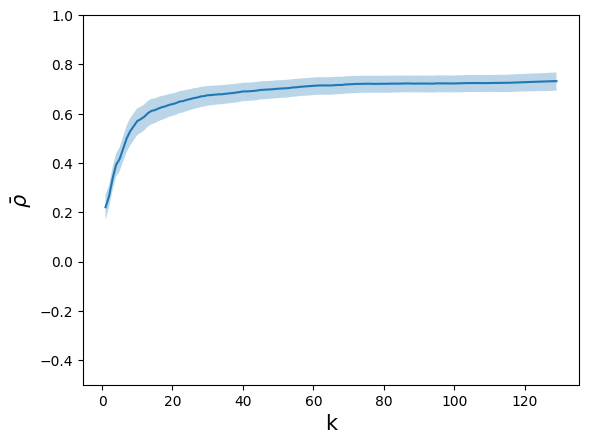

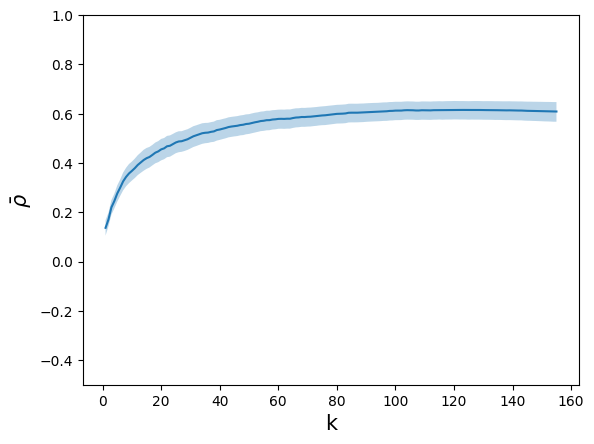

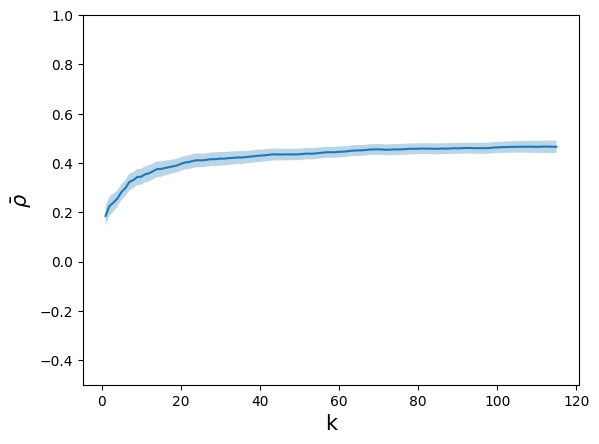

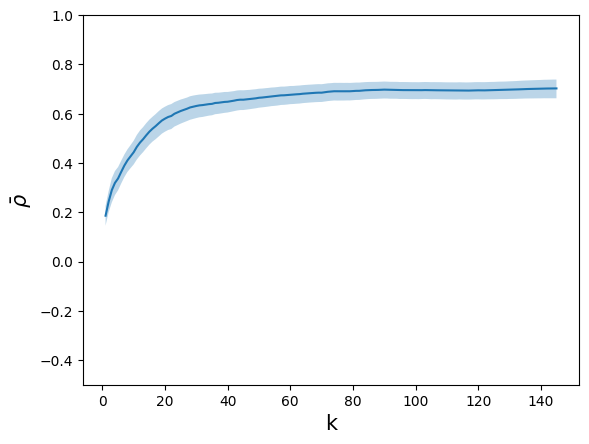

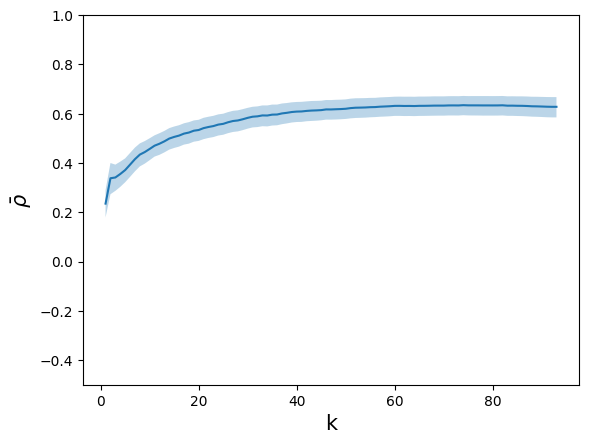

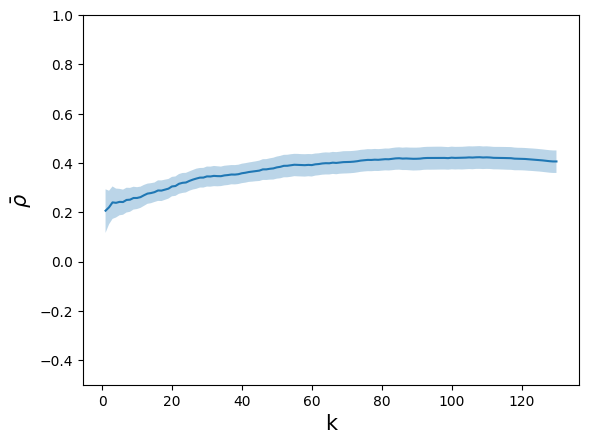

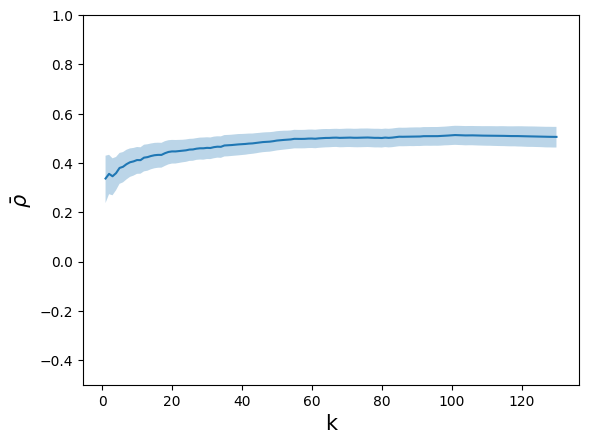

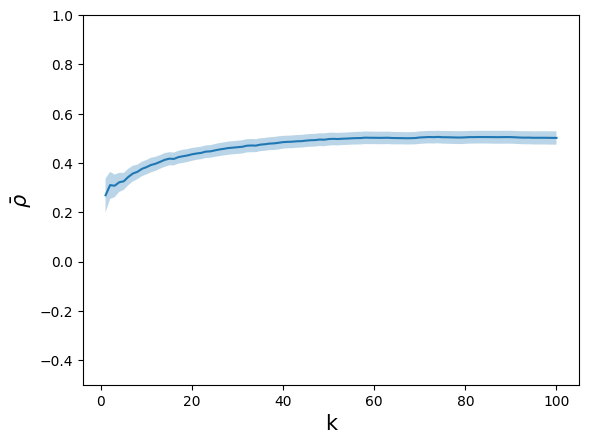

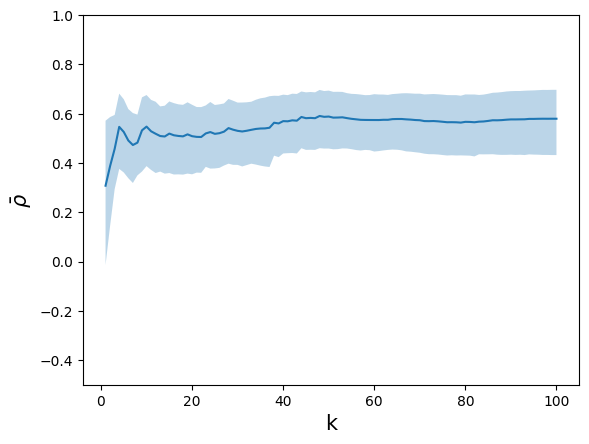

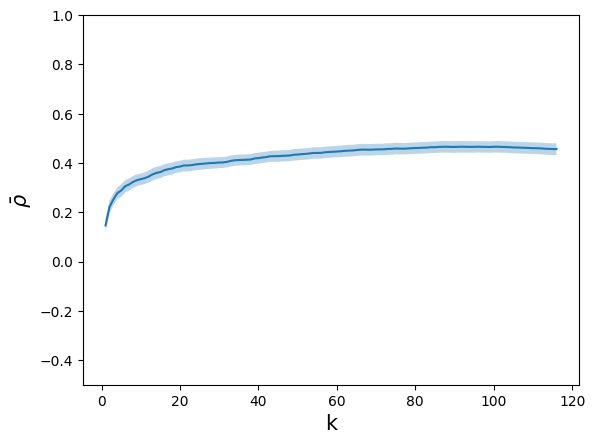

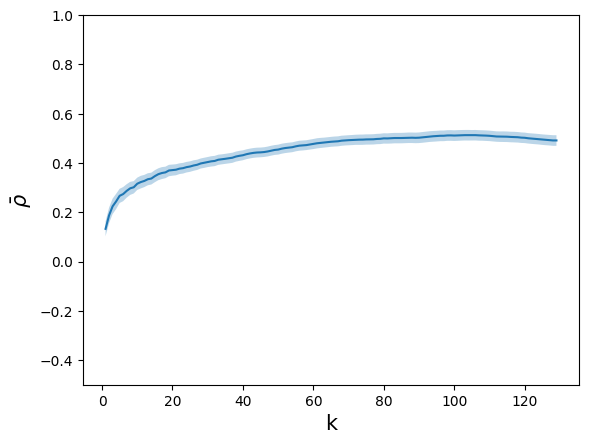

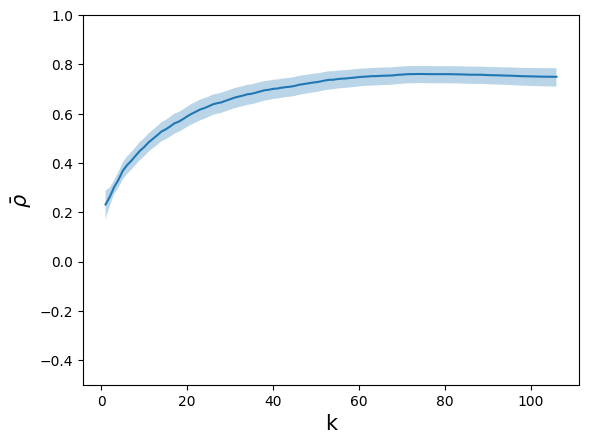

In [ ]:
# ============================================================
# Compute and plot MCWME curves split by prediction polarity
# ============================================================

# Separate model seeds by prediction sign: negative-sum LRP → "opinion" class; positive-sum → "information" class

corrs_full = {}
corrs_full['pos'] = [[] for _ in range(10)]
corrs_full['neg'] = [[] for _ in range(10)]

for text_nbr in range(len(all_parsed_expls['ft'][0])):
    text_len = len(all_parsed_expls['ft'][0][text_nbr])

    ft_expl_nbr_neg = [
        normalize(seed[text_nbr])
        for seed in all_parsed_expls['ft']
        if sum(score for score, _ in seed[text_nbr]) < 0
    ]
    ft_expl_nbr_pos = [
        seed[text_nbr]
        for seed in all_parsed_expls['ft']
        if sum(score for score, _ in seed[text_nbr]) > 0
    ]

    if not ft_expl_nbr_neg:
        corrs_full['neg'][text_nbr].append(None)
    else:
        corrs_full['neg'][text_nbr].append(
            compute_pearson_corr(
                ft_expl_nbr_neg,
                list(range(1, text_len + 2)),
                smooth=False,
                order=1,
            )
        )

    if not ft_expl_nbr_pos:
        corrs_full['pos'][text_nbr].append(None)
    else:
        corrs_full['pos'][text_nbr].append(
            compute_pearson_corr(
                ft_expl_nbr_pos,
                list(range(1, text_len + 2)),
                smooth=False,
                order=1,
            )
        )

    if corrs_full['neg'][text_nbr] != [None]:
        mcwme_plot(corrs_full['neg'][text_nbr], text_nbr, 'opin')
    if corrs_full['pos'][text_nbr] != [None]:
        mcwme_plot(corrs_full['pos'][text_nbr], text_nbr, 'info')

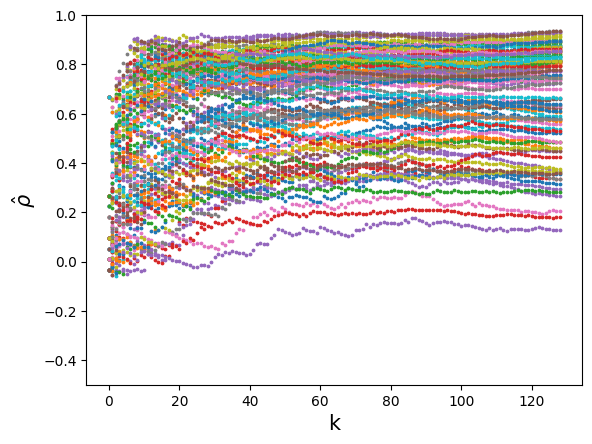

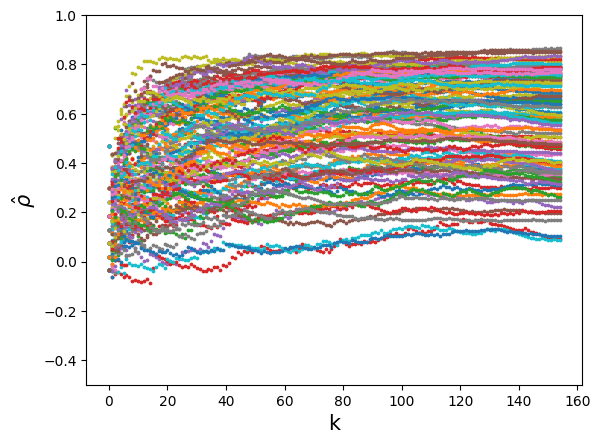

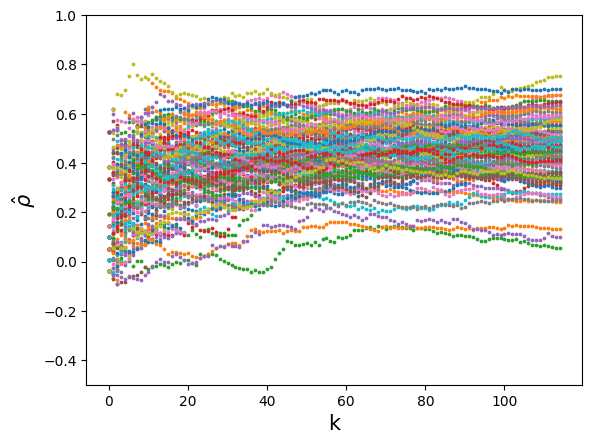

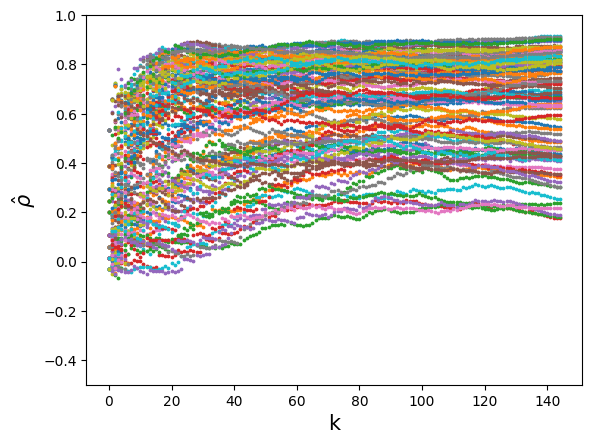

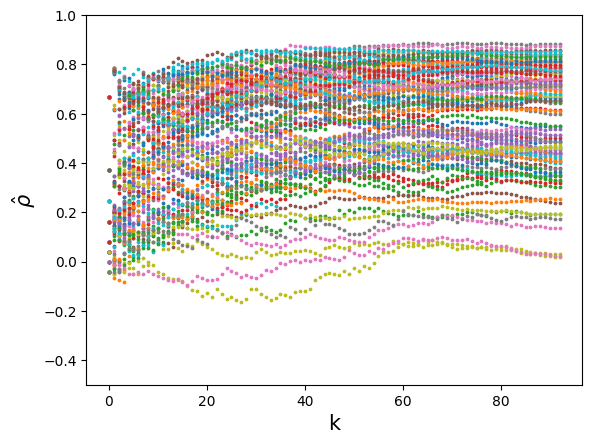

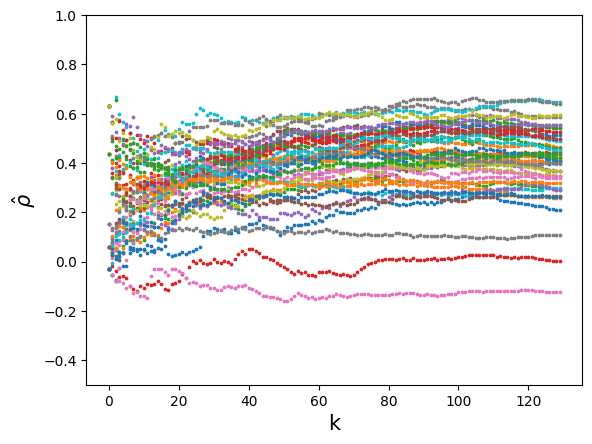

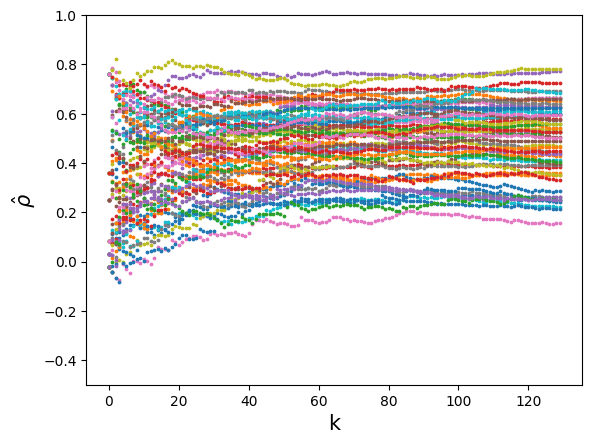

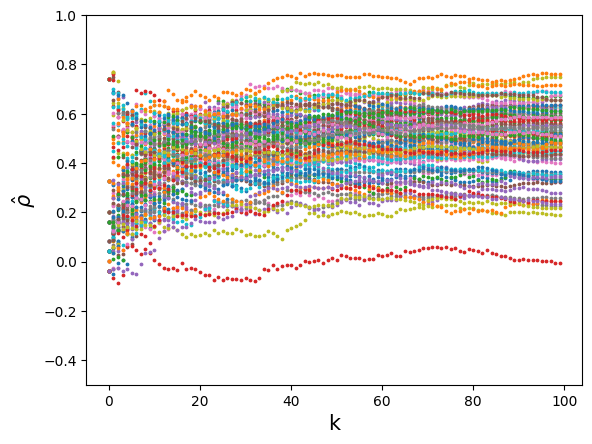

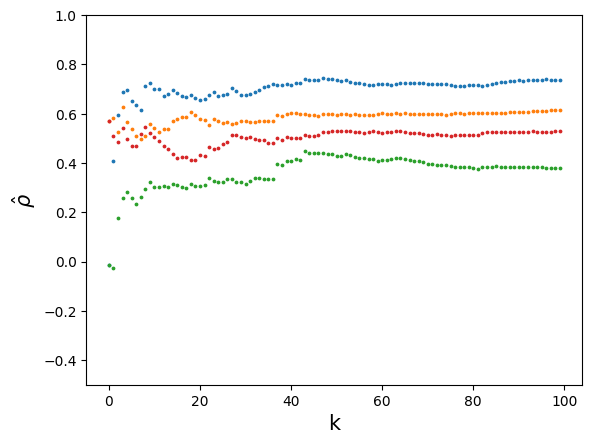

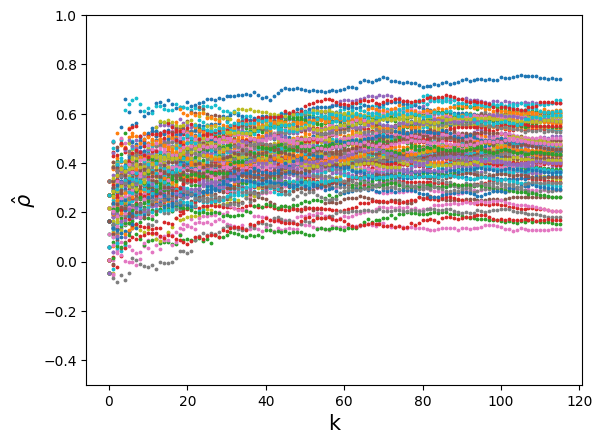

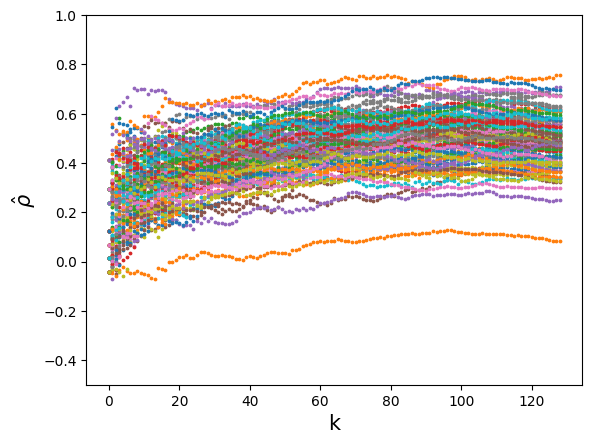

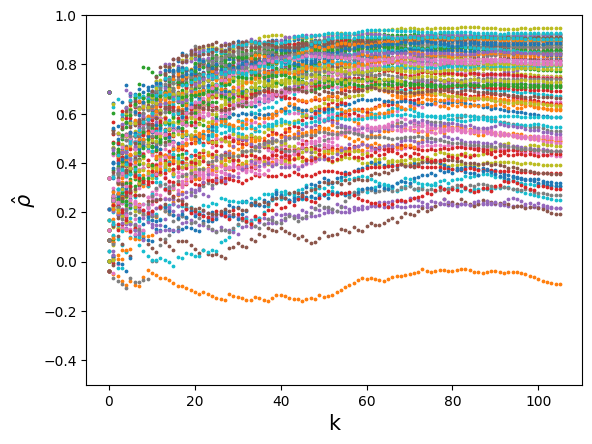

In [ ]:
# ============================================================
# Scatter plots of leave-one-out correlations by polarity
# ============================================================

# Re-run the same polarity split but for raw per-annotator correlations (scatter_plot=True) instead of aggregated bounds

corrs_full = {}
corrs_full['pos'] = [[] for _ in range(10)]
corrs_full['neg'] = [[] for _ in range(10)]

for text_nbr in range(len(all_parsed_expls['ft'][0])):
    text_len = len(all_parsed_expls['ft'][0][text_nbr])

    ft_expl_nbr_neg = [
        normalize(seed[text_nbr])
        for seed in all_parsed_expls['ft']
        if sum(score for score, _ in seed[text_nbr]) < 0
    ]
    ft_expl_nbr_pos = [
        seed[text_nbr]
        for seed in all_parsed_expls['ft']
        if sum(score for score, _ in seed[text_nbr]) > 0
    ]

    if ft_expl_nbr_neg:
        _, _, _, scatter_vals = compute_pearson_corr(
            ft_expl_nbr_neg,
            list(range(1, text_len + 2)),
            smooth=False,
            order=1,
            scatter_plot=True,
        )
        scatter_plot(scatter_vals, text_nbr, 'opin')

    if ft_expl_nbr_pos:
        _, _, _, scatter_vals = compute_pearson_corr(
            ft_expl_nbr_pos,
            list(range(1, text_len + 2)),
            smooth=False,
            order=1,
            scatter_plot=True,
        )
        scatter_plot(scatter_vals, text_nbr, 'info')

# TOP-1 & TOP-N tokens MCWME computation

In [ ]:
corrs = {
    label: [[] for _ in range(10)]
    for label in ['ft1', 'ftN', 'human1', 'humanN']
}

explanations = {
    label: [{'info': [], 'opin': []} for _ in range(10)]
    for label in ['ft', 'hu', 'ft_d', 'ft_hu']
}

In [ ]:
# ============================================================
# Top-N MCWME for fine-tuned model (k = full text length)
# ============================================================

corrs['ftN'] = [[] for _ in range(10)]

for text_nbr in range(len(all_parsed_expls['ft'][0])):

    ft_expl_nbr_neg = [
        normalize(seed[text_nbr])
        for seed in all_parsed_expls['ft']
        if sum(score for score, _ in seed[text_nbr]) < 0
    ]
    ft_expl_nbr_pos = [
        seed[text_nbr]
        for seed in all_parsed_expls['ft']
        if sum(score for score, _ in seed[text_nbr]) > 0
    ]

    if not ft_expl_nbr_neg:
        corrs['ftN'][text_nbr].append(None)
    else:
        explanations['ft'][text_nbr]['opin'] = ft_expl_nbr_neg
        corrs['ftN'][text_nbr].append(
            compute_pearson_corr(ft_expl_nbr_neg, [-1], smooth=False, order=1)
        )

    if not ft_expl_nbr_pos:
        corrs['ftN'][text_nbr].append(None)
    else:
        explanations['ft'][text_nbr]['info'] = ft_expl_nbr_pos
        corrs['ftN'][text_nbr].append(
            compute_pearson_corr(ft_expl_nbr_pos, [-1], smooth=False, order=1)
        )

In [ ]:
# ============================================================
# Top-1 MCWME for fine-tuned model (k = 1 token)
# ============================================================

corrs['ft1'] = [[] for _ in range(10)]

for text_nbr in range(len(all_parsed_expls['ft'][0])):

    ft_expl_nbr_neg = [
        normalize(seed[text_nbr])
        for seed in all_parsed_expls['ft']
        if sum(score for score, _ in seed[text_nbr]) < 0
    ]
    ft_expl_nbr_pos = [
        seed[text_nbr]
        for seed in all_parsed_expls['ft']
        if sum(score for score, _ in seed[text_nbr]) > 0
    ]

    if not ft_expl_nbr_neg:
        corrs['ft1'][text_nbr].append(None)
    else:
        corrs['ft1'][text_nbr].append(
            compute_pearson_corr(ft_expl_nbr_neg, [1], smooth=False, order=1)
        )

    if not ft_expl_nbr_pos:
        corrs['ft1'][text_nbr].append(None)
    else:
        corrs['ft1'][text_nbr].append(
            compute_pearson_corr(ft_expl_nbr_pos, [1], smooth=False, order=1)
        )

In [ ]:
# ============================================================
# Top-N MCWME for human annotators (k = full text length)
# ============================================================

corrs['humanN'] = [[] for _ in range(10)]

for text_nbr, text_expls in all_parsed_expls['human'].items():

    # Exclude annotators who provided no highlights
    hu_expl_nbr = [e for e in text_expls if sum(score for score, _ in e) != 0]

    if human_expls_preds[text_nbr][0] > human_expls_preds[text_nbr][1]:
        # Majority voted for the opinion class
        explanations['hu'][text_nbr]['opin'] = hu_expl_nbr
        corrs['humanN'][text_nbr] += (
            compute_pearson_corr(hu_expl_nbr, [-1], smooth=False, order=1, duplicate=True),
            None,
        )
    else:
        # Majority voted for the information class
        explanations['hu'][text_nbr]['info'] = hu_expl_nbr
        corrs['humanN'][text_nbr] += (
            None,
            compute_pearson_corr(hu_expl_nbr, [-1], smooth=False, order=1, duplicate=True),
        )

In [ ]:
# ============================================================
# Top-1 MCWME for human annotators (k = 1 token)
# ============================================================

corrs['human1'] = [[] for _ in range(10)]

for text_nbr, text_expls in all_parsed_expls['human'].items():

    hu_expl_nbr = [e for e in text_expls if sum(score for score, _ in e) != 0]

    if human_expls_preds[text_nbr][0] > human_expls_preds[text_nbr][1]:
        corrs['human1'][text_nbr] += (
            compute_pearson_corr(hu_expl_nbr, [1], smooth=False, order=1, duplicate=True),
            None,
        )
    else:
        corrs['human1'][text_nbr] += (
            None,
            compute_pearson_corr(hu_expl_nbr, [1], smooth=False, order=1, duplicate=True),
        )

# Discretization of explanations

In [ ]:
# ============================================================
# Discretize continuous LRP scores into 4 importance levels
# ============================================================

def discretize(expl, bpts=[0.165, 0.50, 0.835], flags=[True, True, True]):
    """
    Map continuous relevance scores to a 4-level color scale.

    Importance levels and their visual encoding:
        0    → white  (irrelevant)
        0.33 → yellow (low relevance)
        0.66 → orange (medium relevance)
        1    → red    (high relevance)

    Parameters
    ----------
    expl : list[tuple[float, str]]
        Token-score pairs with scores normalized to [0, 1].
    bpts : list[float]
        Three breakpoints separating the four levels.
    flags : list[bool]
        Toggle each non-zero level on/off: [red, orange, yellow].

    Returns
    -------
    list[tuple[float, str]]
        Explanation with discretized scores.
    """
    d_expl = []
    for value, word in expl:
        if value <= bpts[0]:
            new_value = 0       # white  — irrelevant
        elif value <= bpts[1] and flags[2]:
            new_value = 0.33    # yellow — low relevance
        elif value <= bpts[2] and flags[1]:
            new_value = 0.66    # orange — medium relevance
        elif flags[0]:
            new_value = 1       # red    — high relevance
        else:
            new_value = 0
        d_expl.append((new_value, word))
    return d_expl

In [ ]:
# ============================================================
# Color histogram helpers
# ============================================================

def color_hist(d_expl):
    """
    Count tokens at each discretized importance level for one explanation.

    Parameters
    ----------
    d_expl : list[tuple[float, str]]
        Discretized explanation (scores in {0, 0.33, 0.66, 1}).

    Returns
    -------
    dict[float, int]
        Token counts keyed by importance level.
    """
    d_hist = {level: 0 for level in [0, 0.33, 0.66, 1]}
    for value, _ in d_expl:
        d_hist[value] += 1
    return d_hist


def full_color_hist(d_hists, text_nbr=0):
    """
    Aggregate per-seed color histograms for one text (model explanations).

    Parameters
    ----------
    d_hists : list[list[dict]]
        Color histograms indexed by [seed][text_nbr].
    text_nbr : int
        Index of the text to aggregate over.

    Returns
    -------
    dict[float, int]
        Summed token counts across all seeds for the given text.
    """
    full_hist = {level: 0 for level in [0, 0.33, 0.66, 1]}
    for d_hist in d_hists:
        for level, count in d_hist[text_nbr].items():
            full_hist[level] += count
    return full_hist


def full_color_hist_hu(d_hists):
    """
    Aggregate per-annotator color histograms for one text (human explanations).

    Parameters
    ----------
    d_hists : list[dict]
        One color histogram per annotator, already scoped to a single text.

    Returns
    -------
    dict[float, int]
        Summed token counts across all annotators.
    """
    full_hist = {level: 0 for level in [0, 0.33, 0.66, 1]}
    for d_hist in d_hists:
        for level, count in d_hist.items():
            full_hist[level] += count
    return full_hist

In [ ]:
# ============================================================
# Contiguous-span statistics for discretized explanations
# ============================================================

def compute_interval_length(expl, nbr_only=False):
    """
    Compute statistics about contiguous runs of same-level tokens.

    Runs (intervals) capture whether highlighted tokens form compact
    spans or are scattered — a proxy for explanation coherence.

    Parameters
    ----------
    expl : list[tuple[float, str]]
        Discretized explanation.
    nbr_only : bool
        If True  → return number of intervals per level.
        If False → return mean interval length per level.

    Returns
    -------
    dict[float, float | int]
        Interval count or mean length, keyed by importance level.
    """
    interval_lengths = {level: [] for level in [0, 0.33, 0.66, 1]}
    last_v = expl[0][0]
    run_size = 1

    for v, _ in expl[1:]:
        if v != last_v:
            interval_lengths[last_v].append(run_size)
            run_size = 1
        else:
            run_size += 1
        last_v = v

    # Flush the final run
    interval_lengths[last_v].append(run_size)

    if nbr_only:
        return {level: len(runs) for level, runs in interval_lengths.items()}
    else:
        return {
            level: sum(runs) / len(runs) if runs else 0
            for level, runs in interval_lengths.items()
        }

### color and interval statistics for human annotations

In [ ]:
hists           = {name: [{} for _ in range(10)] for name in ['ft_d', 'ft_hu', 'hu']}
interval_lengths = {name: [{} for _ in range(10)] for name in ['ft_d', 'ft_hu', 'hu']}
interval_nbrs   = {name: [{} for _ in range(10)] for name in ['ft_d', 'ft_hu', 'hu']}

# Pre-compute per-annotator histograms and interval stats for each text,
# excluding annotators who provided no highlights (sum == 0)
color_hists_hu = [
    [color_hist(e) for e in text_expls if sum(score for score, _ in e) != 0]
    for _, text_expls in all_parsed_expls['human'].items()
]
interval_nbr_hu = [
    [compute_interval_length(e, nbr_only=True)  for e in text_expls if sum(score for score, _ in e) != 0]
    for _, text_expls in all_parsed_expls['human'].items()
]
interval_length_hu = [
    [compute_interval_length(e, nbr_only=False) for e in text_expls if sum(score for score, _ in e) != 0]
    for _, text_expls in all_parsed_expls['human'].items()
]

# Aggregate across annotators and normalise interval stats by annotator count
for text_nbr in range(10):
    nbr_of_annot = len(interval_length_hu[text_nbr])

    hists['hu'][text_nbr] = full_color_hist_hu(color_hists_hu[text_nbr])

    interval_lengths['hu'][text_nbr] = {
        color: total / nbr_of_annot
        for color, total in full_color_hist_hu(interval_length_hu[text_nbr]).items()
    }

    interval_nbrs['hu'][text_nbr] = {
        color: total / nbr_of_annot
        for color, total in full_color_hist_hu(interval_nbr_hu[text_nbr]).items()
    }

### Plotting MCWME histograms for different explanation methods

In [ ]:
# ============================================================
# Top-1 and Top-N MCWME for discretized model explanations
# (fixed breakpoints: LRP-d)
# ============================================================

# LRP-d uses uniform breakpoints (0.25 / 0.50 / 0.75) to discretize continuous relevance scores before computing MCWME.

corrs['ft_d1'] = [[] for _ in range(10)]
corrs['ft_dN'] = [[] for _ in range(10)]

bpts = [0.25, 0.50, 0.75]

for text_nbr in range(len(all_parsed_expls['ft'][0])):

    ft_expl_nbr_neg = [
        discretize(normalize(seed[text_nbr]), bpts=bpts)
        for seed in all_parsed_expls['ft']
        if sum(score for score, _ in seed[text_nbr]) < 0
    ]
    ft_expl_nbr_pos = [
        discretize(seed[text_nbr], bpts=bpts)
        for seed in all_parsed_expls['ft']
        if sum(score for score, _ in seed[text_nbr]) > 0
    ]

    # ---- Opinion class (negative-sum seeds) ----
    if not ft_expl_nbr_neg:
        corrs['ft_d1'][text_nbr].append(None)
        corrs['ft_dN'][text_nbr].append(None)
        hists['ft_d'][text_nbr][0]           = None
        interval_lengths['ft_d'][text_nbr][0] = None
        interval_nbrs['ft_d'][text_nbr][0]    = None
    else:
        explanations['ft_d'][text_nbr]['opin'] = ft_expl_nbr_neg
        corrs['ft_d1'][text_nbr].append(
            compute_pearson_corr(ft_expl_nbr_neg, [1],  smooth=False, duplicate=True, order=1)
        )
        corrs['ft_dN'][text_nbr].append(
            compute_pearson_corr(ft_expl_nbr_neg, [-1], smooth=False, order=1)
        )

        nbr_of_seeds = len(ft_expl_nbr_neg)
        hists['ft_d'][text_nbr][0] = full_color_hist_hu(
            [color_hist(e) for e in ft_expl_nbr_neg]
        )
        interval_lengths['ft_d'][text_nbr][0] = {
            color: v / nbr_of_seeds
            for color, v in full_color_hist_hu(
                [compute_interval_length(e, nbr_only=False) for e in ft_expl_nbr_neg]
            ).items()
        }
        interval_nbrs['ft_d'][text_nbr][0] = {
            color: v / nbr_of_seeds
            for color, v in full_color_hist_hu(
                [compute_interval_length(e, nbr_only=True) for e in ft_expl_nbr_neg]
            ).items()
        }

    # ---- Information class (positive-sum seeds) ----
    if not ft_expl_nbr_pos:
        corrs['ft_d1'][text_nbr].append(None)
        corrs['ft_dN'][text_nbr].append(None)
        hists['ft_d'][text_nbr][1]           = None
        interval_lengths['ft_d'][text_nbr][1] = None
        interval_nbrs['ft_d'][text_nbr][1]    = None
    else:
        explanations['ft_d'][text_nbr]['info'] = ft_expl_nbr_pos
        corrs['ft_d1'][text_nbr].append(
            compute_pearson_corr(ft_expl_nbr_pos, [1],  smooth=False, duplicate=True, order=1)
        )
        corrs['ft_dN'][text_nbr].append(
            compute_pearson_corr(ft_expl_nbr_pos, [-1], smooth=False, order=1)
        )

        nbr_of_seeds = len(ft_expl_nbr_pos)
        hists['ft_d'][text_nbr][1] = full_color_hist_hu(
            [color_hist(e) for e in ft_expl_nbr_pos]
        )
        interval_lengths['ft_d'][text_nbr][1] = {
            color: v / nbr_of_seeds
            for color, v in full_color_hist_hu(
                [compute_interval_length(e, nbr_only=False) for e in ft_expl_nbr_pos]
            ).items()
        }
        interval_nbrs['ft_d'][text_nbr][1] = {
            color: v / nbr_of_seeds
            for color, v in full_color_hist_hu(
                [compute_interval_length(e, nbr_only=True) for e in ft_expl_nbr_pos]
            ).items()
        }

print(corrs['ft_d1'])
print(corrs['ft_dN'])

In [ ]:
# ============================================================
# Plot color-level histograms: LRP-d vs. human (per text)
# ============================================================

def plot_hists(hist1, hist2, title, percentage=True, labels=[0], ylim=1, legend='', hatch=''):
    """
    Side-by-side bar chart comparing two color-level histograms.

    Model histogram (hist1) is shown in light grey; human histogram
    (hist2) in dark grey. Bars are placed at x and x+0.1 respectively
    so the four importance levels remain visually aligned.

    Parameters
    ----------
    hist1 : dict[float, int | float]
        Model histogram (LRP-d or LRP-hu).
    hist2 : dict[float, int | float]
        Human annotator histogram.
    title : str
        Plot title and output filename (saved under Plots/).
    percentage : bool
        If True, normalise both histograms to sum to 1.
    labels : list
        Unused; retained for API compatibility.
    ylim : float
        Upper y-axis limit when percentage=False.
    legend : str
        Legend label for hist1.
    hatch : str
        Hatch pattern for hist1 bars (e.g. '//' for LRP-hu).
    """
    if percentage:
        heights1 = [v / sum(hist1.values()) for v in hist1.values()]
        heights2 = [v / sum(hist2.values()) for v in hist2.values()]
        plt.ylim([0, 1])
    else:
        heights1 = list(hist1.values())
        heights2 = list(hist2.values())
        plt.ylim(0, ylim)

    plt.bar(
        x=hist1.keys(), height=heights1, width=0.1,
        label=legend, color="#bbbbbb", edgecolor='black', hatch=hatch,
    )
    plt.bar(
        x=[k + 0.1 for k in hist2.keys()], height=heights2, width=0.1,
        label='Human', color="#444444", edgecolor='black',
    )

    plt.xticks(
        [0.05, 0.38, 0.71, 1.05],
        ['Not Important', 'Slightly Important', 'Important', 'Very Important'],
        fontsize=10,
    )
    plt.gca().yaxis.tick_left()
    plt.legend(loc='upper right')
    plt.savefig(f"Plots/{title}", bbox_inches='tight')
    plt.show()




In [ ]:
# Plot LRP-d vs. human color distributions for each text
percentage = True
for text_nbr in range(10):
    # Default to the info label (1) when no opinion seeds exist;
    # texts 5 and 6 have seeds in both polarity groups
    labels = [1] if hists['ft_d'][text_nbr][0] is None else [0]
    if text_nbr in [5, 6]:
        labels = [0, 1]

    for label in labels:
        title = (
            f"Color distribution for text {text_nbr + 1}, LRP-d "
            f"({'opin' if label == 0 else 'info'})"
        )
        plot_hists(
            hists['ft_d'][text_nbr][label],
            hists['hu'][text_nbr],
            title,
            percentage=percentage,
            labels=labels,
            legend='LRP Linear',
        )

### Tweaked breakpoints

In [ ]:
# ============================================================
# Human-aligned breakpoints for discretization (LRP-hu)
# ============================================================

def build_full_expls(expls, text_nbr):
    """
    Flatten per-seed explanations for a single text into one list.

    Parameters
    ----------
    expls : list[list[list[tuple]]]
        All seeds, each containing explanations per text.
    text_nbr : int
        Index of the text to extract.

    Returns
    -------
    list[tuple[float, str]]
        All token-score pairs from all seeds for the given text.
    """
    return [token for seed_expl in expls for token in seed_expl[text_nbr]]


def align_intervals(props_humans, full_lrp_expls):
    """
    Derive breakpoints that match the human color distribution.

    Sorts all LRP scores by magnitude and places breakpoints at the
    quantiles implied by the human histogram proportions, so that
    the resulting LRP-hu discretization has the same level frequencies
    as the human annotations.

    Parameters
    ----------
    props_humans : dict[float, int | float]
        Human color histogram (raw counts; normalised internally).
    full_lrp_expls : list[tuple[float, str]]
        All token-score pairs across seeds for one text.

    Returns
    -------
    list[float]
        Three breakpoints [bp0, bp1, bp2] aligned to human proportions.
    """
    sorted_expls = sorted(full_lrp_expls, key=lambda a: abs(a[0]))
    proportions  = [v / sum(props_humans.values()) for v in props_humans.values()]

    cumulative, bpts = 0, []
    for prop in proportions:
        cumulative += prop
        idx = round(cumulative * len(full_lrp_expls))
        bpts.append(abs(sorted_expls[idx - 1][0]))

    return bpts

In [ ]:
# ============================================================
# Top-1 and Top-N MCWME for human-aligned discretization (LRP-hu)
# ============================================================

corrs['ft_hu1'] = [[] for _ in range(10)]
corrs['ft_huN'] = [[] for _ in range(10)]

for text_nbr in range(len(all_parsed_expls['ft'][0])):

    negs = [s for s in all_parsed_expls['ft'] if sum(score for score, _ in s[text_nbr]) < 0]
    poss = [s for s in all_parsed_expls['ft'] if sum(score for score, _ in s[text_nbr]) > 0]

    # ---- Opinion class (negative-sum seeds) ----
    if not negs:
        corrs['ft_hu1'][text_nbr].append(None)
        corrs['ft_huN'][text_nbr].append(None)
        hists['ft_hu'][text_nbr][0]            = None
        interval_lengths['ft_hu'][text_nbr][0] = None
        interval_nbrs['ft_hu'][text_nbr][0]    = None
    else:
        bpts_neg       = align_intervals(hists['hu'][text_nbr], build_full_expls(negs, text_nbr))
        ft_expl_nbr_neg = [
            discretize(normalize(seed[text_nbr]), bpts=bpts_neg)
            for seed in all_parsed_expls['ft']
            if sum(score for score, _ in seed[text_nbr]) < 0
        ]

        explanations['ft_hu'][text_nbr]['opin'] = ft_expl_nbr_neg
        corrs['ft_hu1'][text_nbr].append(
            compute_pearson_corr(ft_expl_nbr_neg, [1],  smooth=False, duplicate=True, order=1)
        )
        corrs['ft_huN'][text_nbr].append(
            compute_pearson_corr(ft_expl_nbr_neg, [-1], smooth=False, order=1)
        )

        nbr_of_seeds = len(negs)
        hists['ft_hu'][text_nbr][0] = full_color_hist_hu(
            [color_hist(e) for e in ft_expl_nbr_neg]
        )
        interval_lengths['ft_hu'][text_nbr][0] = {
            color: v / nbr_of_seeds
            for color, v in full_color_hist_hu(
                [compute_interval_length(e, nbr_only=False) for e in ft_expl_nbr_neg]
            ).items()
        }
        interval_nbrs['ft_hu'][text_nbr][0] = {
            color: v / nbr_of_seeds
            for color, v in full_color_hist_hu(
                [compute_interval_length(e, nbr_only=True) for e in ft_expl_nbr_neg]
            ).items()
        }

    # ---- Information class (positive-sum seeds) ----
    if not poss:
        corrs['ft_hu1'][text_nbr].append(None)
        corrs['ft_huN'][text_nbr].append(None)
        hists['ft_hu'][text_nbr][1]            = None
        interval_lengths['ft_hu'][text_nbr][1] = None
        interval_nbrs['ft_hu'][text_nbr][1]    = None
    else:
        bpts_pos       = align_intervals(hists['hu'][text_nbr], build_full_expls(poss, text_nbr))
        ft_expl_nbr_pos = [
            discretize(seed[text_nbr], bpts=bpts_pos)
            for seed in all_parsed_expls['ft']
            if sum(score for score, _ in seed[text_nbr]) > 0
        ]

        explanations['ft_hu'][text_nbr]['info'] = ft_expl_nbr_pos
        corrs['ft_hu1'][text_nbr].append(
            compute_pearson_corr(ft_expl_nbr_pos, [1],  smooth=False, duplicate=True, order=1)
        )
        corrs['ft_huN'][text_nbr].append(
            compute_pearson_corr(ft_expl_nbr_pos, [-1], smooth=False, order=1)
        )

        nbr_of_seeds = len(poss)
        hists['ft_hu'][text_nbr][1] = full_color_hist_hu(
            [color_hist(e) for e in ft_expl_nbr_pos]
        )
        interval_lengths['ft_hu'][text_nbr][1] = {
            color: v / nbr_of_seeds
            for color, v in full_color_hist_hu(
                [compute_interval_length(e, nbr_only=False) for e in ft_expl_nbr_pos]
            ).items()
        }
        interval_nbrs['ft_hu'][text_nbr][1] = {
            color: v / nbr_of_seeds
            for color, v in full_color_hist_hu(
                [compute_interval_length(e, nbr_only=True) for e in ft_expl_nbr_pos]
            ).items()
        }

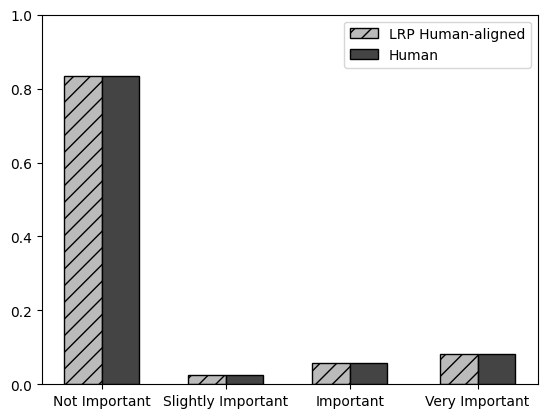

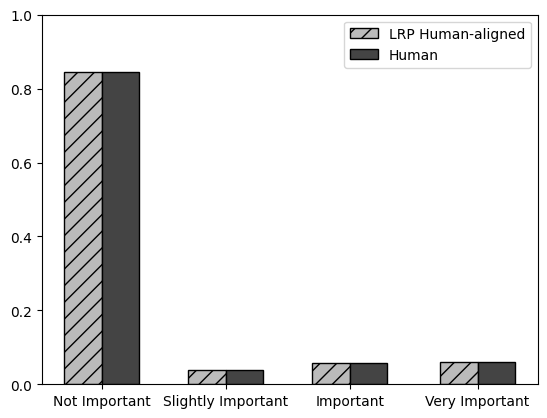

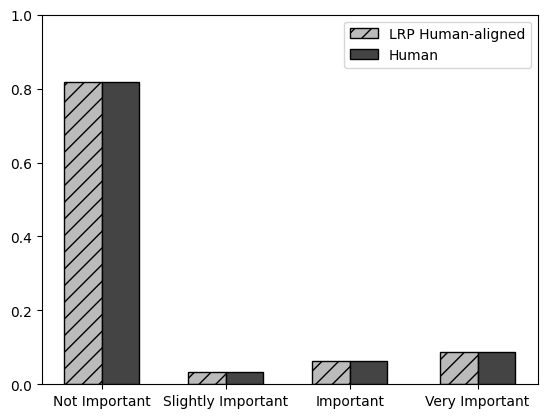

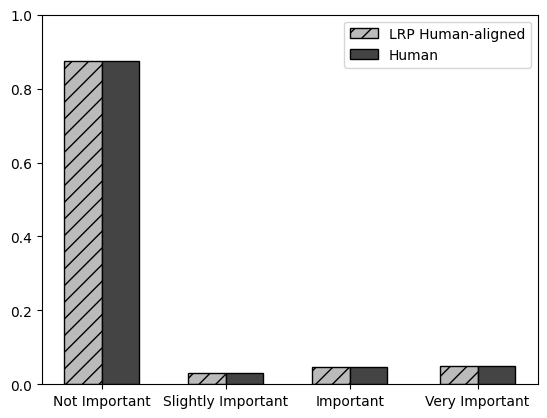

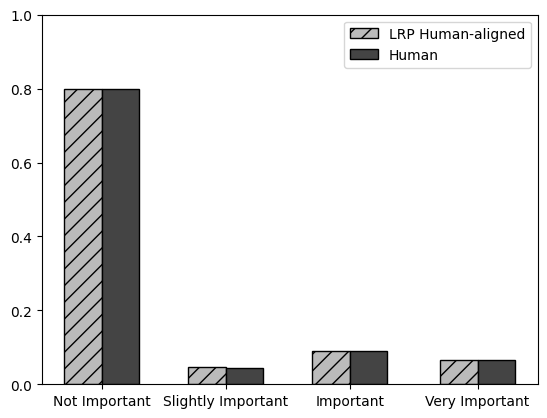

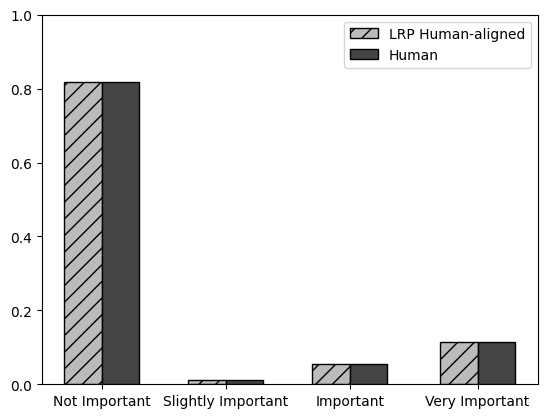

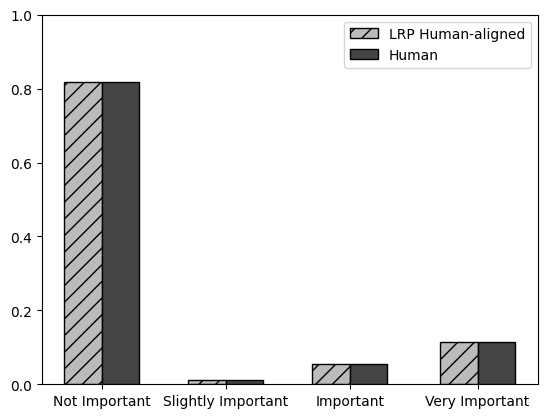

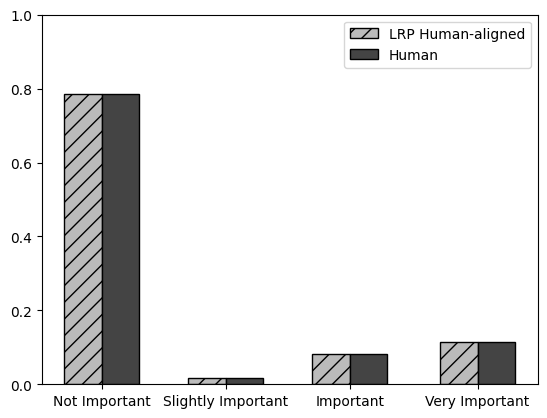

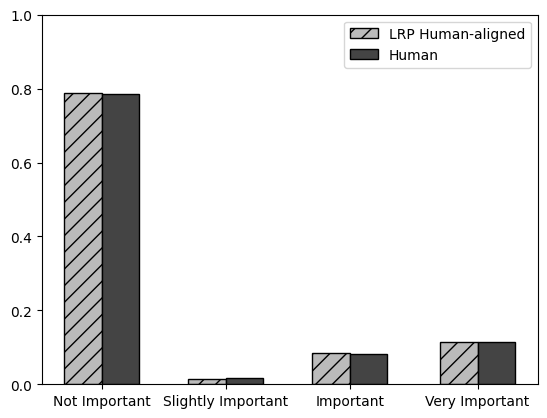

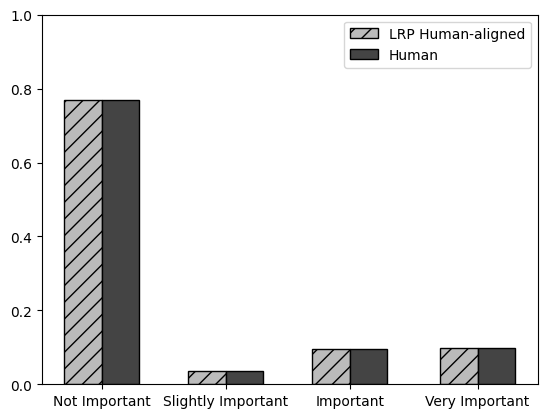

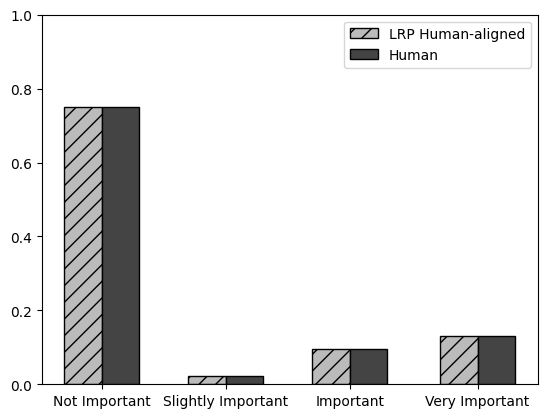

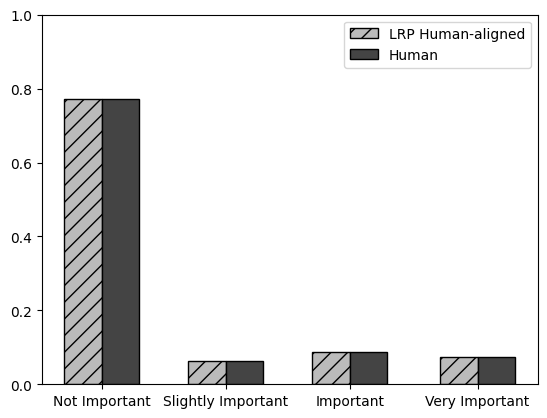

In [ ]:
# ============================================================
# Plot color distributions: LRP-hu vs. human (per text)
# ============================================================

percentage = True
for text_nbr in range(10):
    labels = [1] if hists['ft_hu'][text_nbr][0] is None else [0]
    if text_nbr in [5, 6]:
        labels = [0, 1]

    for label in labels:
        title = (
            f"Color distribution for text {text_nbr + 1}, LRP-hu "
            f"({'opin' if label == 0 else 'info'})"
        )
        plot_hists(
            hists['ft_hu'][text_nbr][label],
            hists['hu'][text_nbr],
            title,
            percentage=percentage,
            labels=labels,
            legend='LRP Human-aligned',
            hatch='//',
        )

In [ ]:
# ============================================================
# Plot mean interval counts: LRP-d vs. LRP-hu vs. human
# ============================================================

def plot_hist_list(hist_list, color_list, hatch_list, label_list, title, ylim=1):
    """
    Grouped bar chart overlaying multiple color histograms.

    Each histogram occupies a 0.1-wide bar; groups are spaced at 1.5×
    the importance-level key so adjacent groups do not overlap.

    Parameters
    ----------
    hist_list   : list[dict[float, float]]  Histograms to overlay.
    color_list  : list[str]                 Bar fill colour per histogram.
    hatch_list  : list[str | None]          Hatch pattern per histogram.
    label_list  : list[str]                 Legend label per histogram.
    title       : str                       Output filename stem.
    ylim        : float                     Upper y-axis limit.
    """
    for pos, hist in enumerate(hist_list):
        x = [1.5 * k + pos * 0.1 for k in hist.keys()]
        plt.bar(
            x=x,
            height=list(hist.values()),
            width=0.1,
            label=label_list[pos],
            color=color_list[pos],
            hatch=hatch_list[pos],
            edgecolor='black',
        )
    plt.ylim(0, ylim)
    plt.xticks(
        [0.1, 0.6, 1.1, 1.6],
        ['Not Important', 'Slightly Important', 'Important', 'Very Important'],
        fontsize=10,
    )
    plt.gca().yaxis.tick_left()
    plt.legend(loc='upper right')
    plt.savefig(f"Plots/{title}", bbox_inches='tight')
    plt.show()

ylims       = [30] * 10
color_list  = ['#bbbbbb', '#bbbbbb', '#444444']
hatch_list  = [None, '//', None]
label_list  = ['LRP Linear', 'LRP Human-aligned', 'Human']

for text_nbr in range(10):
    labels = [1] if hists['ft_hu'][text_nbr][0] is None else [0]
    if text_nbr in [5, 6]:
        labels = [0, 1]

    for label in labels:
        title = (
            f"Avg interval nbr for text {text_nbr + 1}, all "
            f"({'opin' if label == 0 else 'info'})"
        )
        plot_hist_list(
            [
                interval_nbrs['ft_d'][text_nbr][label],
                interval_nbrs['ft_hu'][text_nbr][label],
                interval_nbrs['hu'][text_nbr],
            ],
            color_list, hatch_list, label_list,
            title, ylim=ylims[text_nbr],
        )

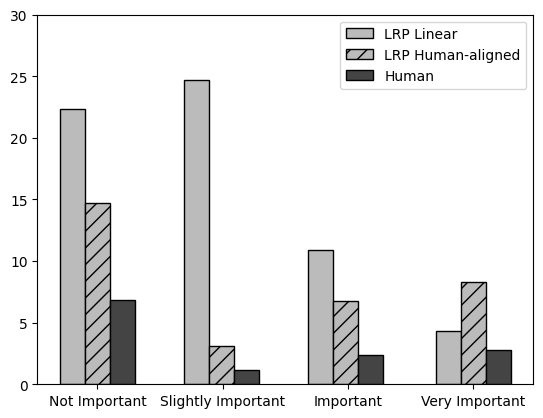

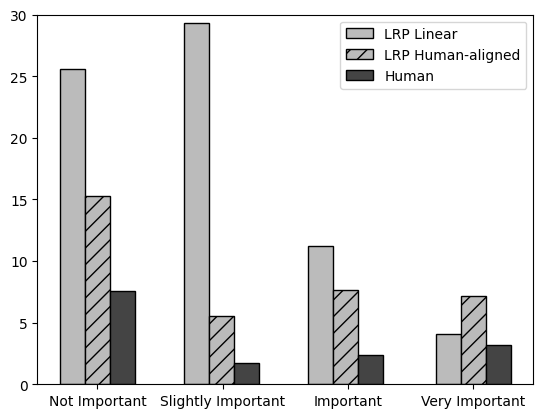

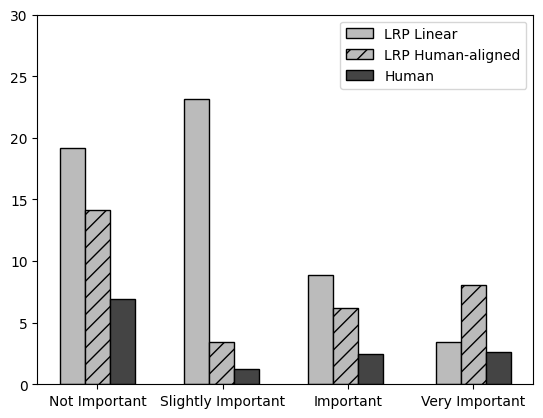

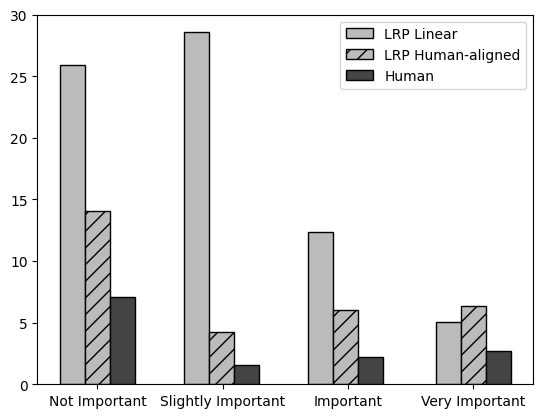

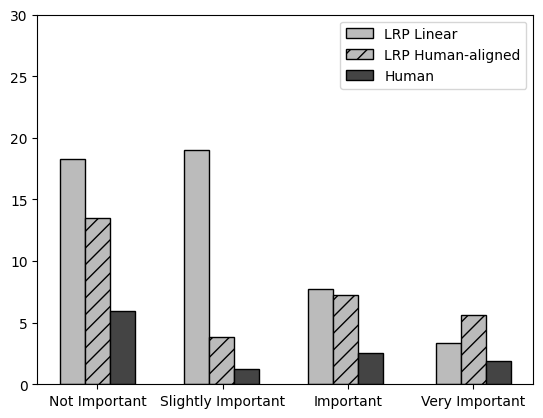

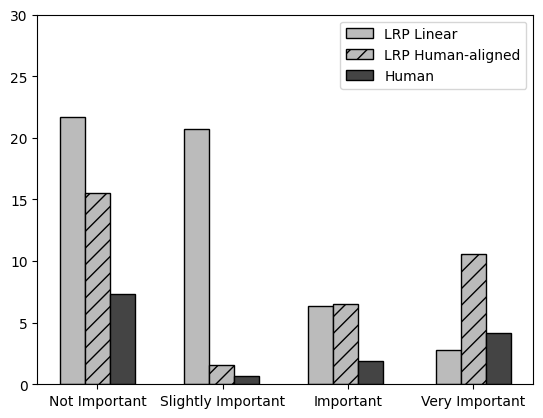

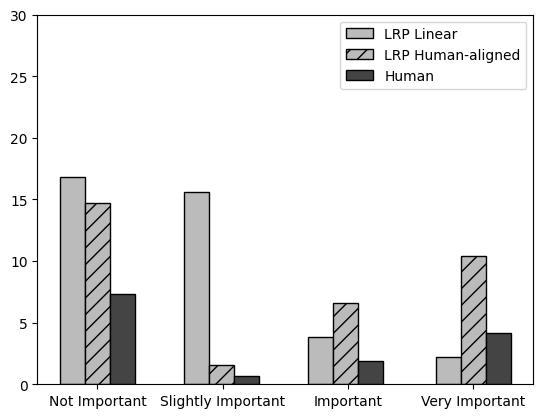

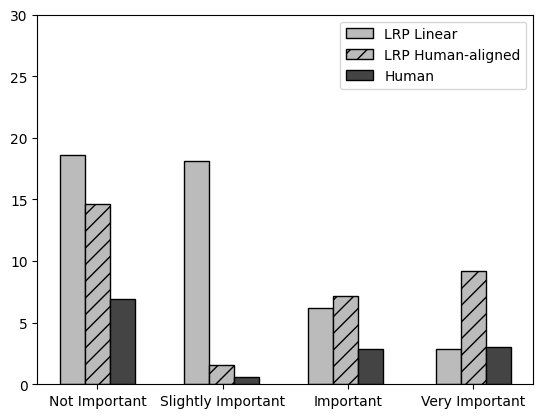

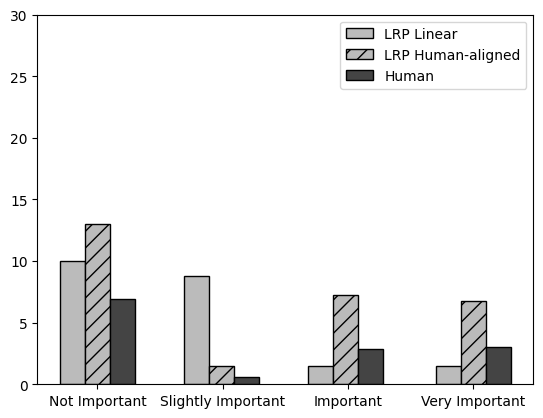

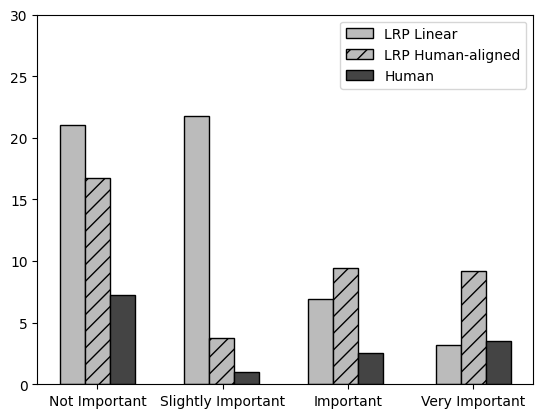

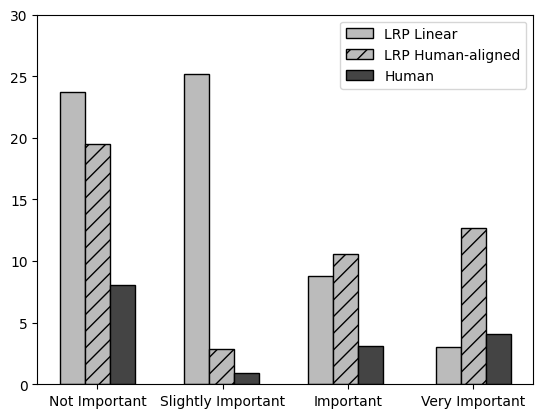

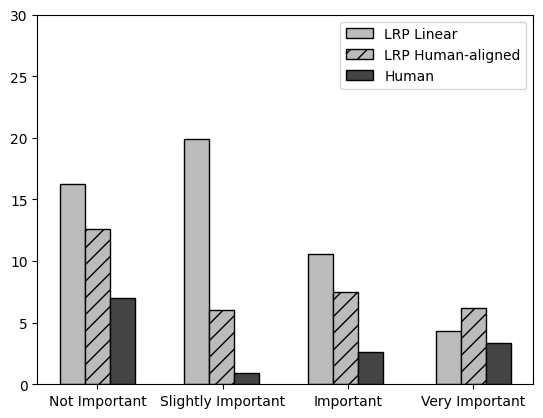

In [ ]:
ylims = [30,30,30,30,30,30,30,30,30,30]
color_list = ['#bbbbbb', '#bbbbbb', '#444444'] 
hatch_list = [None, '//', None]
label_list = ['LRP Linear', 'LRP Human-aligned', 'Human']

for text_nbr in range(10):
    labels = [1] if hists['ft_hu'][text_nbr][0] is None else [0]
    if text_nbr in [5, 6]:
        labels = [0, 1]
        
    for label in labels:
        hist1 = interval_nbrs['ft_d'][text_nbr][label]
        hist2 = interval_nbrs['ft_hu'][text_nbr][label]
        hist3 = interval_nbrs['hu'][text_nbr]
        if label == 0:
            title = f"Avg interval nbr for text {text_nbr+1}, all (opin)"
        else:
            title = f"Avg interval nbr for text {text_nbr+1}, all (info)"
        plot_hist_list([hist1, hist2, hist3], color_list, hatch_list, label_list, title, ylim=ylims[text_nbr])

In [ ]:
# Save all aligned explanation sets for downstream analysis
with open('Explanation_file', 'wb') as f:
    pickle.dump(explanations, f)

In [56]:
print(corrs['ft1'][0][1][0])

[0.16610027037534572]


In [65]:
colors = {'ft1': 'orange',
          'ftN': 'red',
          'human1': 'violet',
          'humanN': 'purple',
          'ft_d1' : 'green',
          'ft_dN' : 'blue',
          'ft_hu1': 'chocolate',
          'ft_huN': 'saddlebrown'}

legend_label = {'ft1': 'LRP top-1',
                'ftN': 'LRP top-n',
                'human1': 'Human top-1',
                'humanN': 'Human top-n',
                'ft_d1' : 'LRP Linear top-1',
                'ft_dN' : 'LRP Linear top-n',
                'ft_hu1': 'LRP Human-aligned top-1',
                'ft_huN': 'LRP Human-aligned top-n'}


In [ ]:
# ============================================================
# MCWME comparison plot (opinion-only variant for texts 5 & 6)
# ============================================================

def plot_MCWME_comparison(selected_corrs, corrs, order=None):
    """
    Scatter plot of MCWME values with confidence bands across texts.

    Parameters
    ----------
    selected_corrs : list[str]
        Subset of condition keys to overlay (must be in `corrs`).
    corrs : dict[str, list]
        MCWME results indexed by [condition][text_nbr] → (opin, info).
    order : list[int]
        Permutation mapping internal text index to x-axis position.
    """
    offset = 0

    for model in corrs:
        if model not in selected_corrs:
            continue

        color = colors[model]
        plot_list = []
        true_pos  = 0

        for pos, (opin, info) in enumerate(corrs[model]):
            if pos not in [5, 6]:
                # Single-class texts: use whichever polarity is present
                corr = info if opin is None else opin
                plot_list.append((corr[0], corr[1], corr[2], color, true_pos))
                true_pos += 1
            else:
                # Texts 5 & 6: plot opinion class only (paper convention)
                corr = opin
                plot_list.append((corr[0], corr[1], corr[2], color, true_pos))
                true_pos += 1

        # Draw confidence bands where the interval is non-degenerate
        for lb, val, hb, color, x in plot_list:
            if hb[0] - lb[0] != 0:
                plt.fill_between(
                    [order[x] + offset - 0.09, order[x] + offset + 0.09],
                    lb, hb, alpha=0.5, color=color,
                )

        # Scatter markers for non-zero mean correlations
        xs = [order[i[4]] + offset for i in plot_list if i[1][0] != 0]
        ys = [i[1]                 for i in plot_list if i[1][0] != 0]
        plt.scatter(xs, ys, marker='_', facecolor=color,
                    label=legend_label[model], s=16)
        offset += 0.05

    plt.vlines(4.5, 0, 1, colors='black', linestyles='dashed')
    plt.legend(loc='upper right', markerscale=5)
    plt.xlim([-1, 10])
    plt.xticks([i for i in range(10)], ['N1', 'N2', 'N3', 'N4', 'N5', 'O1', 'O2', 'O3', 'O4', 'O5'])
    plt.savefig(f"Plots/MCWME_{'+'.join(selected_corrs)}", bbox_inches='tight')
    plt.show()


# --- Order corresponding to randomized text order for annotation ---
text_order = [0, 1, 5, 2, 3, 6, 7, 8, 9, 4]

plot_MCWME_comparison(['human1', 'humanN', 'ft1',    'ftN'],    corrs, order=text_order)
plot_MCWME_comparison(['ft1',    'ftN',    'ft_d1',  'ft_dN'],  corrs, order=text_order)
plot_MCWME_comparison(['ft_d1',  'ft_dN',  'ft_hu1', 'ft_huN'], corrs, order=text_order)
plot_MCWME_comparison(['human1', 'humanN', 'ft_hu1', 'ft_huN'], corrs, order=text_order)

# BoxPlots

In [ ]:
# ============================================================
# Boxplot helper: per-token agreement distributions
# ============================================================

def create_boxplot(bins1, bins2):
    """
    Two-panel boxplot comparing token-level agreement distributions.

    Parameters
    ----------
    bins1 : dict[int, list[float]]
        Per-token agreement vectors for the first condition.
    bins2 : dict[int, list[float]]
        Per-token agreement vectors for the second condition.
    """
    plt.rcParams["figure.figsize"] = (20, 3)
    x = list(bins1.keys())

    ax1 = plt.subplot(2, 1, 1)
    ax1.boxplot(bins1.values(), bootstrap=None)
    ax1.plot([i + 1 for i in x], [sum(v) / len(v) for v in bins1.values()],
             'g_', markersize=15)
    ax1.set_yticks([0, 0.5, 1], [0, 0.5, 1], fontsize=15, rotation=90)
    ax1.yaxis.tick_right()
    ax1.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

    ax2 = plt.subplot(2, 1, 2)
    ax2.boxplot(bins2.values(), bootstrap=None)
    ax2.plot([i + 1 for i in x], [sum(v) / len(v) for v in bins2.values()],
             'g_', markersize=15)
    ax2.set_yticks([0, 0.5, 1], [0, 0.5, 1], fontsize=15, rotation=90)
    ax2.set_xticks([i + 1 for i in x], [i + 1 for i in x], fontsize=15, rotation=90)
    ax2.yaxis.tick_right()

    plt.show()
    plt.rcParams["figure.figsize"] = (5, 5)

In [ ]:
# ============================================================
# Boxplot: Top-1 vs. Top-N agreement within model explanations
# ============================================================

# Only texts where all seeds agree on the predicted class are included

for text_nbr in range(len(explanations['ft'])):
    negs_ft = [normalize(s) for s in explanations['ft'][text_nbr]['opin']]
    poss_ft = [normalize(s) for s in explanations['ft'][text_nbr]['info']]

    # Skip texts where seeds disagree on the predicted class
    if negs_ft and poss_ft:
        continue

    expls = negs_ft if negs_ft else poss_ft
    bins1 = filter_expls(expls, 1)[1]
    binsN = filter_expls(expls, -1)[1]
    create_boxplot(bins1, binsN)

In [ ]:
# ============================================================
# Boxplot: Top-1 model vs. Top-1 human agreement
# ============================================================

for text_nbr in range(len(explanations['ft'])):
    negs_ft = [normalize(s) for s in explanations['ft'][text_nbr]['opin']]
    poss_ft = [normalize(s) for s in explanations['ft'][text_nbr]['info']]

    if negs_ft and poss_ft:
        continue

    ft_expls = negs_ft if negs_ft else poss_ft
    bins1_ft = filter_expls(ft_expls, 1)[1]

    negs_hu = [normalize(s) for s in explanations['hu'][text_nbr]['opin']]
    poss_hu = [normalize(s) for s in explanations['hu'][text_nbr]['info']]

    hu_expls = negs_hu if negs_hu else poss_hu
    print(len(hu_expls[0]), len(ft_expls[0]))   # sanity-check token alignment
    bins1_hu = filter_expls(hu_expls, 1)[1]

    try:
        create_boxplot(bins1_ft, bins1_hu)
    except Exception:
        print(f"Skipped text {text_nbr}")